In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('data_science_job.csv')

In [3]:
df

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14.0,NaN,NaN,42.0,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14.0,NaN,NaN,52.0,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,50-99,Pvt Ltd,44.0,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,0.0,500-999,Pvt Ltd,97.0,0.0


In [4]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [6]:
df.isnull().mean()*100      # the perc of missing value in given data

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [8]:
df.shape

(19158, 13)

In [11]:
col=[var for var in df.columns if df[var].isnull().mean()<0.05 and  df[var].isnull().mean()>0]
col  # this is those col which mean value is in less than 5% and grater than 0

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [12]:
df[col].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14465,0.920,no_enrollment,Phd,20.0,17.0
15817,0.855,no_enrollment,Masters,10.0,NaN
12589,0.920,no_enrollment,Graduate,20.0,54.0
6038,0.893,Part time course,Graduate,6.0,5.0
10510,0.855,Full time course,High School,0.0,6.0


In [14]:
len(df[col].dropna())/len(df)      # this is value if we drop all the nul value so how per they effect our data
             

0.8968577095730244

In [16]:
new_df=df[col].dropna()
df.shape,new_df.shape

((19158, 13), (17182, 5))

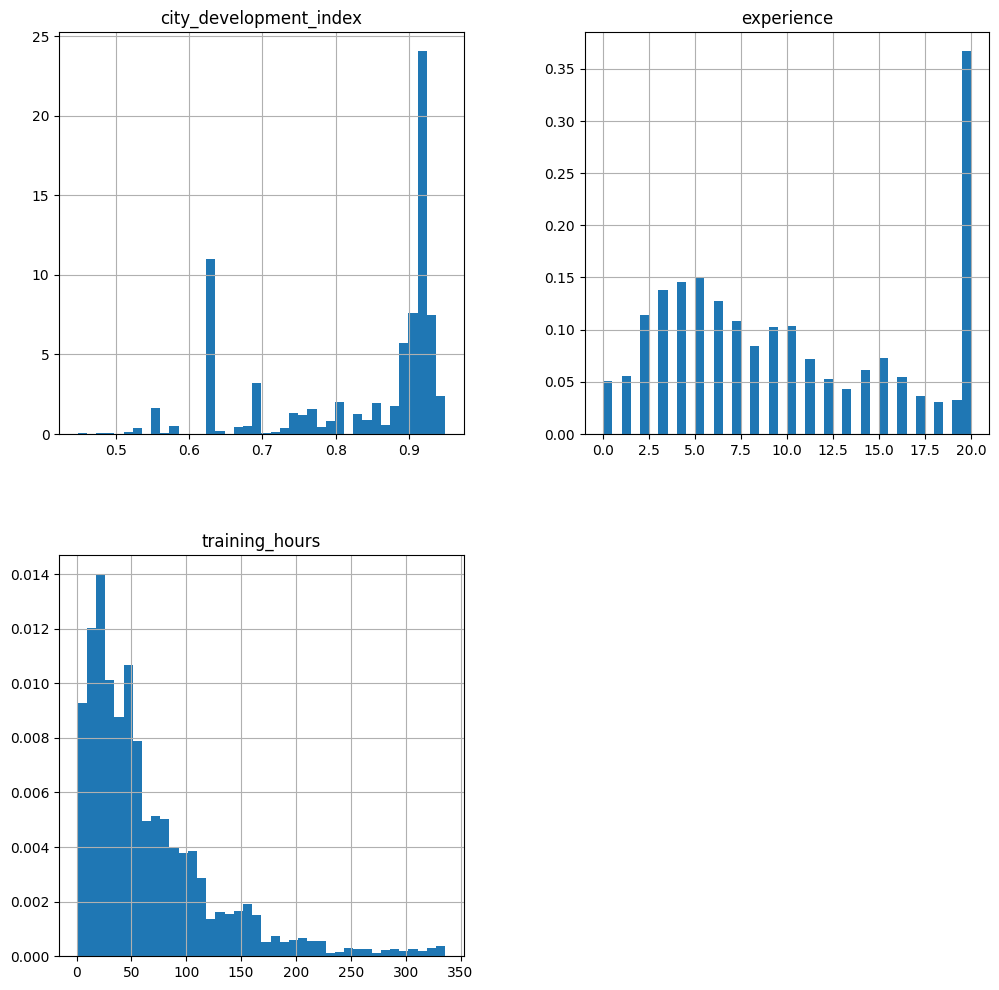

In [19]:
new_df.hist(bins=40, density=True ,figsize=(12,12))
plt.show()

In [28]:
# we wil make the grap and see the diff of the grapgh if it is less and dont show must so we apply cca  while we dont
# so numerical col

<Axes: >

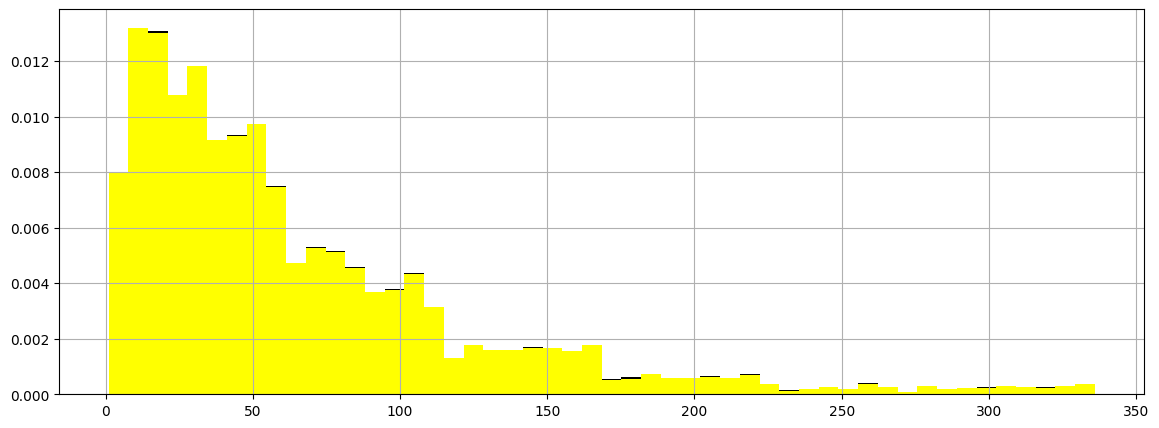

In [25]:
fig=plt.figure(figsize=(14,5))
ax=fig.add_subplot(111)
df['training_hours'].hist(bins=50,ax=ax,density=True, color='black')   # on orignal data
new_df['training_hours'].hist(bins=50,ax=ax,density=True,color='yellow')   # new data

<Axes: >

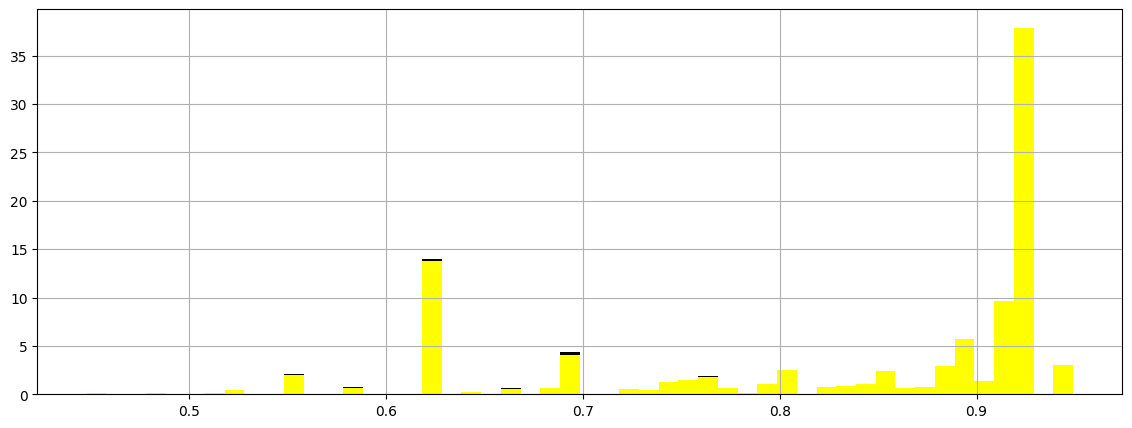

In [26]:
fig=plt.figure(figsize=(14,5))
ax=fig.add_subplot(111)
df['city_development_index'].hist(bins=50,ax=ax,density=True, color='black')   # on orignal data
new_df['city_development_index'].hist(bins=50,ax=ax,density=True,color='yellow')   # new data

<Axes: ylabel='Density'>

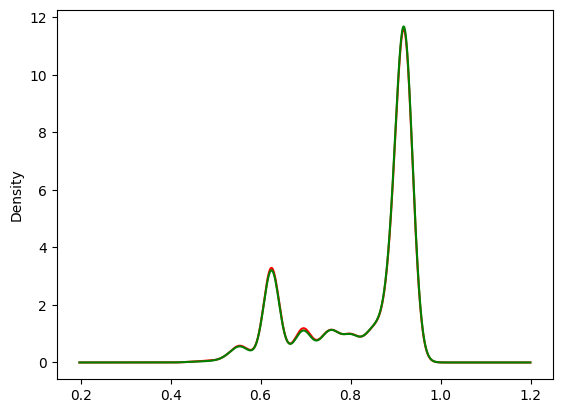

In [27]:
df['city_development_index'].plot.density(color='red')
new_df['city_development_index'].plot.density(color='green')

In [29]:
# now catagorical col

In [30]:
df['enrolled_university'].value_counts() # see the cat

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

In [31]:
df['education_level'].value_counts()      # see the categ

education_level
Graduate          11598
Masters            4361
High School        2017
Phd                 414
Primary School      308
Name: count, dtype: int64

In [33]:
temp=pd.concat([
        df['enrolled_university'].value_counts()/len(df),     # per of orignal cate data
    new_df['enrolled_university'].value_counts()/len(new_df)],axis=1)  # per of new categ datq
# add new colume
temp.columns=['orignal','CCA']
temp

,orignal,CCA
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


In [34]:
# see the resut it dont effect our result after cca

In [35]:
temp=pd.concat([
        df['education_level'].value_counts()/len(df),     # per of orignal cate data
    new_df['education_level'].value_counts()/len(new_df)],axis=1)  # per of new categ datq
# add new colume
temp.columns=['orignal','CCA']
temp

,orignal,CCA
education_level,,
Graduate,0.605387,0.619835
Masters,0.227633,0.234082
High School,0.105282,0.107380
Phd,0.021610,0.022116
Primary School,0.016077,0.016587
